## 0. (Optional) Install dependencies
Run these commands in a terminal or uncomment in Colab/Jupyter to install required packages.

```bash
# pip install --upgrade pip
# pip install tensorflow scikit-learn joblib matplotlib
```

In [1]:
import os
import numpy as np
import joblib
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt

try:
    import tensorflow as tf
    from tensorflow.keras import layers, models
    print('TensorFlow version:', tf.__version__)
except Exception as e:
    print('TensorFlow not installed or failed to import. Install tensorflow before running training cells. Error:', e)

TensorFlow version: 2.20.0


In [4]:
path = "New Plant Diseases Dataset(Augmented)"

if not os.path.exists(path):
    raise FileNotFoundError(f"Provided path does not exist: {path}")

candidate_train_paths = [
    os.path.join(path, "New Plant Diseases Dataset(Augmented)", "train"),
    os.path.join(path, "train"),
    os.path.join(path, "New Plant Diseases Dataset(Augmented)", "New Plant Diseases Dataset(Augmented)", "train"),
    os.path.join(path, "New Plant Diseases Dataset(Augmented)\train"),
]

train_dir = valid_dir = None
for t in candidate_train_paths:
    v = t.replace(os.path.join("train"), os.path.join("valid"))
    if os.path.exists(t) and os.path.exists(v):
        train_dir, valid_dir = t, v
        break

if train_dir is None:
    t_alt = os.path.join(path, "train")
    v_alt = os.path.join(path, "valid")
    if os.path.exists(t_alt) and os.path.exists(v_alt):
        train_dir, valid_dir = t_alt, v_alt

if train_dir is None:
    listing = os.listdir(path)
    raise FileNotFoundError('Could not locate train/ and valid/ directories inside the provided path. Top-level contains: ' + ', '.join(listing))

print('Using train directory:', train_dir)
print('Using valid directory:', valid_dir)


Using train directory: New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\train
Using valid directory: New Plant Diseases Dataset(Augmented)\New Plant Diseases Dataset(Augmented)\valid


In [5]:
import tensorflow as tf
from tensorflow.keras import layers

img_height, img_width = 128, 128
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    valid_dir,
    image_size=(img_height, img_width),
    batch_size=batch_size
)

class_names = train_ds.class_names
num_classes = len(class_names)
print('Found classes:', num_classes)
print('Sample classes:', class_names[:10])

normalization_layer = layers.Rescaling(1./255)
train_ds = train_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(tf.data.AUTOTUNE)
val_ds = val_ds.map(lambda x, y: (normalization_layer(x), y)).cache().prefetch(tf.data.AUTOTUNE)

Found 70295 files belonging to 38 classes.
Found 17572 files belonging to 38 classes.
Found classes: 38
Sample classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy', 'Cherry_(including_sour)___Powdery_mildew', 'Cherry_(including_sour)___healthy', 'Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot', 'Corn_(maize)___Common_rust_', 'Corn_(maize)___Northern_Leaf_Blight']


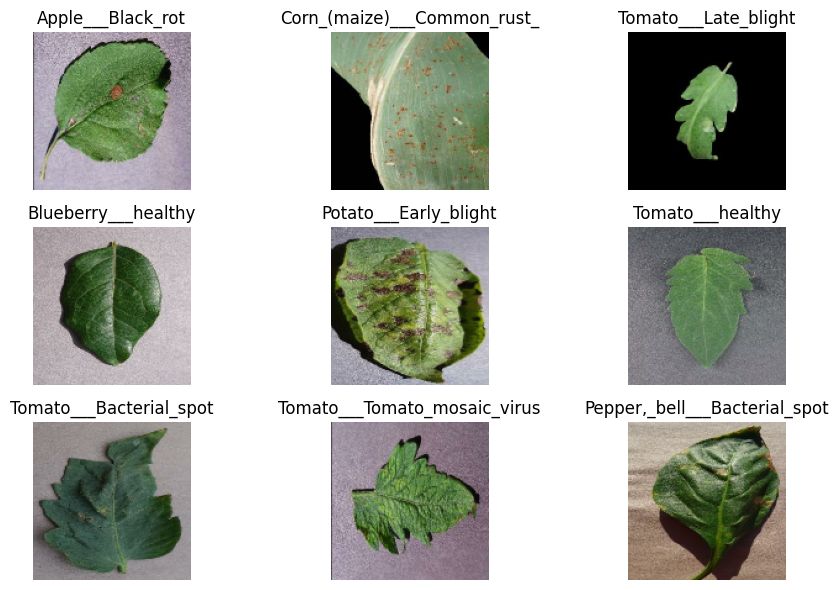

In [6]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
for images, labels in train_ds.take(1):
    for i in range(9):
        ax = plt.subplot(3,3,i+1)
        plt.imshow(images[i].numpy())
        plt.title(class_names[int(labels[i])])
        plt.axis('off')
plt.tight_layout()

In [7]:
from tensorflow.keras import models, layers

def build_cnn(input_shape=(img_height, img_width, 3), num_classes=num_classes):
    model = models.Sequential([
        layers.Conv2D(32, (3,3), activation='relu', input_shape=input_shape),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(64, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        layers.Conv2D(128, (3,3), activation='relu'),
        layers.MaxPooling2D(2,2),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dropout(0.5),
        layers.Dense(num_classes, activation='softmax')
    ])
    model.compile(optimizer='adam',
                  loss='sparse_categorical_crossentropy',
                  metrics=['accuracy'])
    return model

model = build_cnn()
model.summary()

c:\Users\hp\test-app\myvenv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     6,422,784 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         9,766 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,525,798 (24.89 MB)

 Trainable params: 6,525,798 (24.89 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
epochs = 10
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=epochs
)

Epoch 1/10
 597/2197 ━━━━━━━━━━━━━━━━━━━━ 6:28 243ms/step - accuracy: 0.1983 - loss: 2.9463

KeyboardInterrupt: 

In [8]:
import numpy as np
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

y_true = []
y_pred = []
for images, labels in val_ds:
    preds = np.argmax(model.predict(images), axis=1)
    y_true.extend(labels.numpy().tolist())
    y_pred.extend(preds.tolist())

print('Validation Accuracy:', accuracy_score(y_true, y_pred))
print('\nClassification Report:\n', classification_report(y_true, y_pred, target_names=class_names, zero_division=0))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 411ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 131ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 97ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 124ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 101ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 129ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 99ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 102ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 92ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 109ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 96ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/

In [9]:
os.makedirs('model', exist_ok=True)
model.save('model/model.h5')
joblib.dump({'class_names': class_names}, 'model/label_classes.pkl')
print('Saved model to image_classification_model/model/model.h5 and class metadata to image_classification_model/model/label_classes.pkl')


Saved model to image_classification_model/model/model.h5 and class metadata to image_classification_model/model/label_classes.pkl


In [10]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np
import joblib

def load_artifacts(model_path='model/model.h5', meta_path='model/label_classes.pkl'):
    model = load_model(model_path)
    meta = joblib.load(meta_path)
    return model, meta['class_names']

def predict_image(img_path, model, class_names, target_size=(img_height, img_width)):
    img = image.load_img(img_path, target_size=target_size)
    arr = image.img_to_array(img) / 255.0
    arr = np.expand_dims(arr, axis=0)
    preds = model.predict(arr)
    idx = int(np.argmax(preds, axis=1)[0])
    return {'label': class_names[idx], 'confidence': float(np.max(preds))}

# Example usage:
model_loaded, names = load_artifacts()
print(predict_image('image_path', model_loaded, names))


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 206ms/step
{'label': 'Corn_(maize)___Northern_Leaf_Blight', 'confidence': 0.030112063512206078}
